<a href="https://colab.research.google.com/github/JuanZapa7a/AINavalEngineering/blob/main/CS3b-medium_swh_probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="output_png output_subarea output_execute_result">
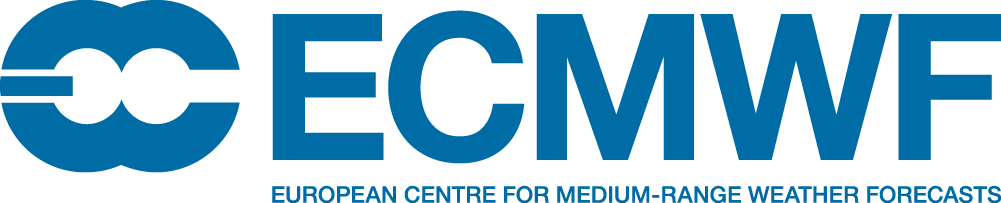
</div>

# 	Probabilities: significant wave height

This notebook will provide you guidance how to explore and plot ECMWF open dataset to produce the map from the ECMWF open charts web product.  
The original product can be found on this link: https://charts.ecmwf.int/products/medium-swh-probability  


<div class="output_png output_subarea output_execute_result">
<center>
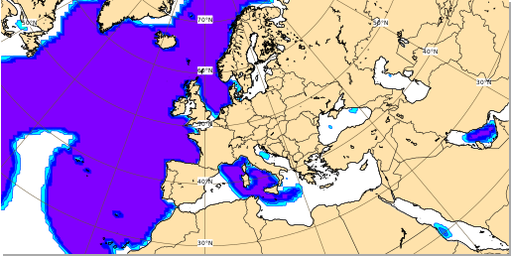</center>
</div>

The full list of available Open data products can be found [here](https://www.ecmwf.int/en/forecasts/datasets/open-data), and more information can be found in the [User documentation](https://confluence.ecmwf.int/display/DAC/ECMWF+open+data%3A+real-time+forecasts+from+IFS+and+AIFS).  

Access to ECMWF Open data is governed by the Creative Commons CC-BY-4.0 licence and associated [Terms of Use](https://apps.ecmwf.int/datasets/licences/general/).  

<sub> In applying this licence, ECMWF does not waive the privileges and immunities granted to it by virtue of its status as an intergovernmental organisation nor does it submit to any jurisdiction </sub>

To find out how to obtain the access to the full forecast dataset at higher resolution please visit our [Access page](https://www.ecmwf.int/en/forecasts/accessing-forecasts).

## Retrieve Data
This product takes in input one of these 4 parameters:

* [Significant wave height of at least 2 m](https://codes.ecmwf.int/grib/param-db/131074)
* [Significant wave height of at least 4 m](https://codes.ecmwf.int/grib/param-db/131075)
* [Significant wave height of at least 6 m](https://codes.ecmwf.int/grib/param-db/131076)
* [Significant wave height of at least 8 m](https://codes.ecmwf.int/grib/param-db/131077)

These are already calculated probabilities, so no need to download all ensemble members.

In this example, we will use:
- [**ecmwf.opendata**](https://github.com/ecmwf/ecmwf-opendata) Client to download the data


First we need to install them in the current Jupyter kernel:  

In [ ]:
!pip install cfgrib xarray cartopy eccodes ecmwf-opendata

In [ ]:
from ecmwf.opendata import Client
client=Client("ecmwf", beta=False)
parameters=['swhg2','swhg4','swhg6','swhg8']
filename='medium-swh-probability.grib'
client.retrieve(date=-1,time=0,step=48,stream='waef',type='ep',levtype='sfc',param=parameters,target=filename)


In client.retrieve, setting date to 0 will download today's data.
Removing date and time altogether from the request will download the latest data.  
Try commenting out date and time to download latest forecast!

## Reading and processing the data
Now we can use **xarray** to read the file.

In [ ]:
import xarray as xr

In [ ]:
data = xr.open_dataset(filename, engine='cfgrib')
data

And an overview of one parameter, where we can see more information, such as units or type of level.

In [ ]:
swhg4 = data['swhg4']
swhg4

We can use **ls()** function to list all the fields in the file we downloaded.

## Plotting the data
And finally, we can plot the data on the map.

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

plt.figure(figsize=(10,6))
ax=plt.axes(projection=ccrs.PlateCarree())
swhg4.plot(ax=ax)
ax.coastlines()
plt.title("SWHG4 Probability")
plt.show()


In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Crear figura
plt.figure(figsize=(12,8))
proj = ccrs.PlateCarree()
ax = plt.axes(projection=proj)

# Añadir costas
ax.coastlines(resolution="50m", color="black")
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")

# Área (equivalente al area=[-90, -180, 90, 180])
ax.set_extent([40, -20, 70, 35], crs=proj)
#area=[30, -20, 70, 40],  # Europa: [lat_min, lon_min, lat_max, lon_max]

# Sombras de fondo (parecido a contourf)
data = swhg4.values
lons = swhg4.longitude.values
lats = swhg4.latitude.values

# Crear niveles similares a Metview
levels = np.linspace(0, 100, 21)

plt.contourf(
    lons,
    lats,
    data,
    levels=levels,
    transform=proj,
    cmap="Blues",
    extend="both"
)

# Título
plt.title("Probabilities: significant wave height > 4 m"
           , fontsize=12)

# Créditos ECMWF
plt.figtext(0.5, -0.1,
            s="\n".join(["© European Centre for Medium-Range Weather Forecasts (ECMWF)",
                           "Source: www.ecmwf.int Licence: CC-BY-4.0 and ECMWF Terms of Use",
                            "https://apps.ecmwf.int/datasets/licences/general/"]),
            wrap=True, horizontalalignment='center', fontsize=9)

plt.colorbar(label="% probabilidad")

plt.show()

plt.savefig('swhg4_probability.png')
plt.close()
print('Plot saved as swhg4_probability.png')

To generate the png file you can run the following cell.

In [ ]:
plt.savefig('swhg4_probability.png')
plt.close()
print('Plot saved as swhg4_probability.png')

Note that plot produced using open data dataset will slightly differ from one from Open Charts. This is due to different resolution of the data.  
Open data is on 0.25x0.25 resolution, while high resolution data is 0.1x0.1 grid.

In [ ]:
from IPython.display import Image
Image('swhg4_probability.png')